# check init transform matrix:


In [15]:
import json
data_path = '/ssd/xiaxinyuan/dataset/3dgs_trajectory_vanilla/6F_v3/trajectory_0/data.json'
data = json.load(open(data_path, 'r'))


In [18]:
import numpy as np
import json
from scipy.interpolate import CubicSpline
def transform_matrix_to_pose(camera_transform_matrix):
    """将4x4变换矩阵转换为位置和朝向
    Args:
        camera_transform_matrix: [4, 4] numpy array
    Returns:
        position: [3,] xyz坐标
        orientation: [4,] 四元数 (x,y,z,w)
    """
    from scipy.spatial.transform import Rotation as R
    
    # 提取位置（前3个元素）
    position = camera_transform_matrix[:3, 3]
    
    # 提取旋转矩阵（左上3x3）并转换为四元数
    rotation_matrix = camera_transform_matrix[:3, :3]
    orientation = R.from_matrix(rotation_matrix).as_quat()  # 返回 [x,y,z,w] 格式的四元数
    
    return position, orientation
# save cam_position and cam_orientation as json file at ＇/ssd/xiaxinyuan/dataset/3dgs_trajectory_h1/＇

def get_trajectory(data_path):
    """提取并过滤3DGS轨迹关键点"""
    # 读取数据
    data = json.load(open(data_path, 'r'))
    cam_positions = []
    cam_orientations = []
    
    def quat_angle_diff(q1, q2):
        """计算两个四元数之间的角度差(弧度)"""
        dot_product = abs(np.dot(q1, q2))
        dot_product = min(dot_product, 1.0)
        return 2 * np.arccos(dot_product)
    
    # 过滤关键点
    for i in range(len(data['camera_trajectory'])):
        position, orientation = transform_matrix_to_pose(
            np.array(data['camera_trajectory'][i]))
        
        if len(cam_positions) == 0:
            # 保留第一个点
            cam_positions.append(list(position))
            cam_orientations.append(list(orientation))
            continue
            
        # 判断距离和角度
        pos_dist = np.linalg.norm(position - cam_positions[-1])
        angle_diff = quat_angle_diff(orientation, cam_orientations[-1])
        
        # 满足任一条件则保留该点:
        # 1. 距离大于0.5米
        # 2. 角度变化大于30度
        if pos_dist > 0.8 or angle_diff > 0.9:
            cam_positions.append(list(position))
            cam_orientations.append(list(orientation))
    
    total_len = np.linalg.norm(np.diff(cam_positions, axis=0), axis=1).sum()
    return cam_positions, cam_orientations, total_len
# data_dir = '/ssd/xiaxinyuan/dataset/3dgs_trajectory_vanilla/6F_v3/'
# import os
# # 遍历data_dir下所有文件夹
# for sub_dir in os.listdir(data_dir):
#     traj_path = os.path.join(data_dir, sub_dir, 'data.json')
#     cam_positions, cam_orientations = get_trajectory(traj_path)

test_file = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/test_with_corner.json'
# cam_positions, cam_orientations, total_len = get_trajectory(data_path)


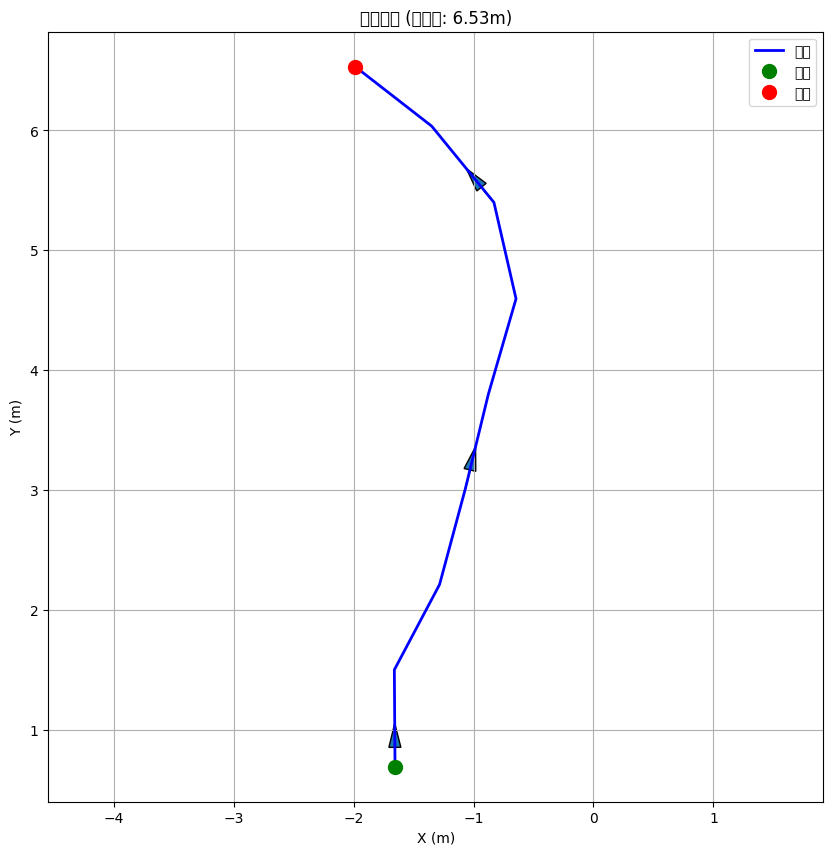

In [19]:
def plot_trajectory(positions):
    """可视化轨迹在XY平面的投影"""
    import matplotlib.pyplot as plt
    
    # 提取x,y坐标
    positions = np.array(positions)
    x = positions[:, 0]
    y = positions[:, 1]
    
    plt.figure(figsize=(10, 10))
    # 绘制轨迹线
    plt.plot(x, y, 'b-', linewidth=2, label='路径')
    # 标记起点和终点
    plt.plot(x[0], y[0], 'go', markersize=10, label='起点')
    plt.plot(x[-1], y[-1], 'ro', markersize=10, label='终点')
    # 添加箭头标记运动方向
    for i in range(len(x)-1):
        if i % 3 == 0:  # 每隔3个点画一个箭头
            plt.arrow(x[i], y[i], 
                     (x[i+1]-x[i])*0.2, (y[i+1]-y[i])*0.2,
                     head_width=0.1, head_length=0.2)
    
    plt.title(f'轨迹投影 (总长度: {np.linalg.norm(np.diff(positions, axis=0), axis=1).sum():.2f}m)')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

# 调用示例:
cam_positions, cam_orientations, total_len = get_trajectory(data_path)
plot_trajectory(cam_positions)


In [8]:
cam_positions

[[-1.6552669747179003, 0.6938351169936088, -0.3642202782518775],
 [-1.744155801092181, 1.1894613741994418, -0.3642202782518775],
 [-1.5661742704918362, 1.6943154333856618, -0.3642202782518775],
 [-1.3094651548977367, 2.157443388934992, -0.3642202782518775],
 [-1.1409280856110937, 2.6642660871379373, -0.3642202782518775],
 [-1.0389048861797967, 3.1598849402663785, -0.3642202782518775],
 [-0.9153142963218167, 3.6697970926588925, -0.3642202782518775],
 [-0.753849040027917, 4.175247095998809, -0.3642202782518775],
 [-0.6366717907769995, 4.670950397717569, -0.3642202782518775],
 [-0.7076046775018054, 5.167091932134307, -0.3642202782518775],
 [-0.9786693743378906, 5.610393789490548, -0.3642202782518775],
 [-1.3065272488667312, 5.991212025176779, -0.3642202782518775],
 [-1.6944830849549362, 6.348938457146043, -0.3642202782518775],
 [-2.120543367315543, 6.611321440939831, -0.3642202782518775]]

In [ ]:

episode_dict = {
    'camera_trajectory': cam_positions,
    'camera_init_orientation': cam_orientations[0]
}

with open(test_file, 'w') as f:
    json.dump(episode_dict, f)



In [11]:
episode_path = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/test.json'
data = json.load(open(episode_path, 'r'))
path = data['camera_trajectory']

In [20]:
# generate path
from path_generation.utils import create_episode, save_episodes
output_dir = 'path_generaton/output'
input_dir = '/ssd/xiaxinyuan/dataset/3dgs_trajectory_vanilla/6F_v3/'
# 读入 input_dir 下长度为4-10m的路径，提取他的idx,使用get_trajectory函数生成camera_positions, camera-orientations
# 调用create_episode函数生成episode_dict,调用save_episodes将生成数据保存在output_dir下
import os
def process_trajectories(input_dir, output_dir):
    """处理所有符合长度要求的轨迹"""
    episodes = []
    episode_id = 0
    
    # 遍历所有轨迹文件夹
    for sub_dir in os.listdir(input_dir):
        traj_path = os.path.join(input_dir, sub_dir, 'data.json')
        if not os.path.exists(traj_path):
            continue
            
        # 获取轨迹数据
        cam_positions, cam_orientations, path_length = get_trajectory(traj_path)
        
        # 过滤4-10m的路径
        if path_length < 4.0 or path_length > 10.0:
            continue
            
        # 创建episode
        episode = create_episode(
            episode_id=episode_id,
            start_position=cam_positions[0],  # 起始位置
            start_rotation=cam_orientations[0],  # 起始朝向
            position=cam_positions[-1],  # 目标位置
            reference_path=cam_positions  # 参考路径
        )
        
        episodes.append(episode)
        episode_id += 1
        
    # 保存所有episodes
    save_episodes(episodes, output_dir)
    print(f"Generated {len(episodes)} episodes")
process_trajectories(input_dir, output_dir)


Data has been written to path_generaton/output/sixth_floor/sixth_floor.json.gz
Generated 1144 episodes


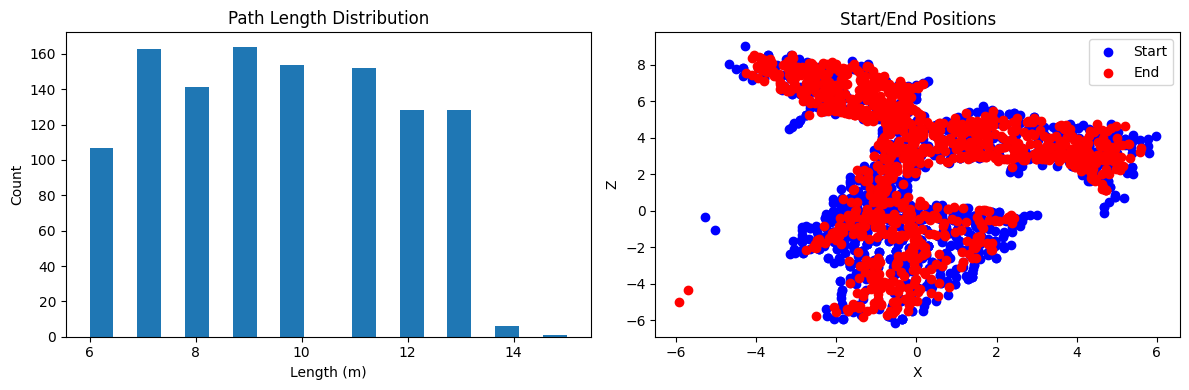

Total episodes: 1144
Average path length: 9.53m
Min path length: 6.00m
Max path length: 15.00m


In [31]:
import gzip
import json
import numpy as np
import matplotlib.pyplot as plt

def read_and_analyze_episodes(output_dir):
    # 读取gz文件
    split = 'sixth_floor'
    input_file = os.path.join(output_dir, split, f"{split}.json.gz")
    
    with gzip.open(input_file, 'rt', encoding='utf-8') as f:
        data = json.load(f)
    
    episodes = data['episodes']
    
    # 统计信息
    num_episodes = len(episodes)
    path_lengths = []
    start_positions = []
    end_positions = []
    cnt=0
    for ep in episodes:
        path = np.array(ep['reference_path'])
        # path_len = np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1))
        path_len = path.shape[0]
        path_lengths.append(path_len)
        start_positions.append(ep['start_position'])
        end_positions.append(ep['goals'][0]['position'])
        # plot_trajectory(path)
        cnt +=1
        # if(cnt>10):
        #     break
    # # 可视化
    plt.figure(figsize=(12, 4))
    
    # # 路径长度分布
    plt.subplot(121)
    plt.hist(path_lengths, bins=20)
    plt.title('Path Length Distribution')
    plt.xlabel('Length (m)')
    plt.ylabel('Count')
    
    # 起点终点分布
    plt.subplot(122)
    start_positions = np.array(start_positions)
    end_positions = np.array(end_positions)
    plt.scatter(start_positions[:,0], start_positions[:,1], c='blue', label='Start')
    plt.scatter(end_positions[:,0], end_positions[:,1], c='red', label='End')
    plt.title('Start/End Positions')
    plt.xlabel('X')
    plt.ylabel('Z')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total episodes: {num_episodes}")
    print(f"Average path length: {np.mean(path_lengths):.2f}m")
    print(f"Min path length: {np.min(path_lengths):.2f}m")
    print(f"Max path length: {np.max(path_lengths):.2f}m")

# 调用函数
output_dir = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/path_generaton/output'
read_and_analyze_episodes(output_dir)


In [32]:

# load original version
def load_data(split):
    ''' Load data based on VLN-CE
    '''
    # dataset_root_dir = base_data_dir # '../VLN/VLNCE/R2R_VLNCE_v1-3'
    dataset_root_dir = '/ssd/xiaxinyuan/code/VLN/VLNCE/R2R_VLNCE_v1-3'
    instruction_list = []
    total_scans = []
    load_data = []
    with gzip.open(os.path.join(dataset_root_dir, f"{split}", f"{split}.json.gz"), 'rt', encoding='utf-8') as f:
        data = json.load(f)
    return data

In [33]:
original_data = load_data('val_seen')


In [34]:
original_data


{'episodes': [{'episode_id': 1,
   'trajectory_id': 37,
   'scene_id': 'mp3d/s8pcmisQ38h/s8pcmisQ38h.glb',
   'start_position': [5.582849979400635,
    -1.6265579462051392,
    2.817889928817749],
   'start_rotation': [-0.0, 0.9659258262890683, -0.0, -0.25881904510252063],
   'info': {'geodesic_distance': 10.39185905456543},
   'goals': [{'position': [11.632800102233887,
      -3.1616740226745605,
      1.9992599487304688],
     'radius': 3.0}],
   'instruction': {'instruction_text': 'Walk down the stairs, turn right, and walk towards place with a rug. Wait near the bench and piano along the right side of the wall. ',
    'instruction_tokens': [2584,
     780,
     2389,
     2222,
     2494,
     1968,
     119,
     2584,
     2452,
     1801,
     2661,
     73,
     2010,
     15,
     2579,
     1563,
     2389,
     290,
     119,
     1773,
     108,
     2389,
     1968,
     2121,
     1605,
     2389,
     2593,
     15]},
   'reference_path': [[5.582849979400635,
     -1.626

In [6]:
import gzip
import os
import json
from vln.src.utils.utils import euler_angles_to_quat, quat_to_euler_angles
def load_sixth_floor_data(split,dataset_root_dir = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/path_generaton/output'):
    ''' Load data based on VLN-CE
    '''

    with gzip.open(os.path.join(dataset_root_dir, f"{split}", f"{split}_with_instr.json.gz"), 'rt', encoding='utf-8') as f:
        data = json.load(f)

    #     for item in data["episodes"]:
    #         item['trajectory_id'] = item['episode_id']
    #         item['original_start_position'] = item['start_position']
    #         item['original_start_rotation'] = item['start_rotation']
    #         init_orientation = item['original_start_rotation']
    #         init_orientation = quat_to_euler_angles(init_orientation)
    #         orientation = [0, 0, init_orientation[2]]
    #         init_orientation = euler_angles_to_quat(orientation)
    #         item['start_rotation'] = init_orientation
    #         item['scan'] = 'sixth_floor'
    # data["sixth_floor"] = data['episodes']
    # del data['episodes']
    return data
# my_data = load_sixth_floor_data('sixth_floor')
# output_file = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/path_generaton/output/sixth_floor.json'
# json.dump(my_data, open(output_file, 'w'), indent=4)



In [10]:
my_data = load_sixth_floor_data('sixth_floor',dataset_root_dir='/ssd/wangliuyi/code/w61_grutopia_main/data/datasets/')
my_data

{'episodes': [{'episode_id': 3,
   'trajectory_id': 1,
   'scene_id': 'sixth_floor',
   'start_position': [-0.0019970180008380065,
    6.884231892169362,
    -0.49204260469601646],
   'start_rotation': [0.06249669525626835,
    0.4960787871720025,
    0.8592336639390564,
    0.10824745148900564],
   'info': {'geodesic_distance': 7.9608235359191895},
   'goals': [{'position': [4.238827428737462,
      3.8604221199330966,
      -0.49204260469601646],
     'radius': 3.0}],
   'instruction': {'instruction_text': 'Shift right, step into the large machine at the back center, swing around the white bench, move past the yellow ladder, pivot right by the yellow crane, and progress straight to the tripod leaning against the wall.',
    'instruction_tokens': [0, 0]},
   'reference_path': [[-0.0019970180008380065,
     6.884231892169362,
     -0.49204260469601646],
    [-0.00124841056597738, 6.052404622886849, -0.49204260469601646],
    [0.15251147927944614, 5.266946931227618, -0.49204260469601646

In [7]:
my_data_with_ins = load_sixth_floor_data('sixth_floor',dataset_root_dir = '/ssd/wangliuyi/code/w61_grutopia_main/data/datasets/')
my_data_with_ins

{'episodes': [{'episode_id': 3,
   'trajectory_id': 1,
   'scene_id': 'sixth_floor',
   'start_position': [-0.0019970180008380065,
    6.884231892169362,
    -0.49204260469601646],
   'start_rotation': [0.06249669525626835,
    0.4960787871720025,
    0.8592336639390564,
    0.10824745148900564],
   'info': {'geodesic_distance': 7.9608235359191895},
   'goals': [{'position': [4.238827428737462,
      3.8604221199330966,
      -0.49204260469601646],
     'radius': 3.0}],
   'instruction': {'instruction_text': 'Shift right, step into the large machine at the back center, swing around the white bench, move past the yellow ladder, pivot right by the yellow crane, and progress straight to the tripod leaning against the wall.',
    'instruction_tokens': [0, 0]},
   'reference_path': [[-0.0019970180008380065,
     6.884231892169362,
     -0.49204260469601646],
    [-0.00124841056597738, 6.052404622886849, -0.49204260469601646],
    [0.15251147927944614, 5.266946931227618, -0.49204260469601646

# test pointcloud

In [7]:
import open3d as o3d

# 遍历main_path下的所有pcd文件，并合并  
main_path = '/ssd/xiaxinyuan/code/w61-grutopia/thirdparty/landmark_isaacsim_interaction/rendered_imgs/sixth_floor/pcd/'
pcd_all = o3d.io.read_point_cloud(main_path + '200.pcd')
for i in range(300, 500, 100):
    pcd = o3d.io.read_point_cloud(main_path + f'{i}.pcd')
    pcd_all += pcd
o3d.io.write_point_cloud('/ssd/xiaxinyuan/code/w61-grutopia/thirdparty/landmark_isaacsim_interaction/rendered_imgs/sixth_floor/pcd/all.pcd', pcd_all)


True

-6.014729976654053 0.865789532661438
1.1254196166992188 9.221243858337402
-1.493769645690918 3.8317391872406006


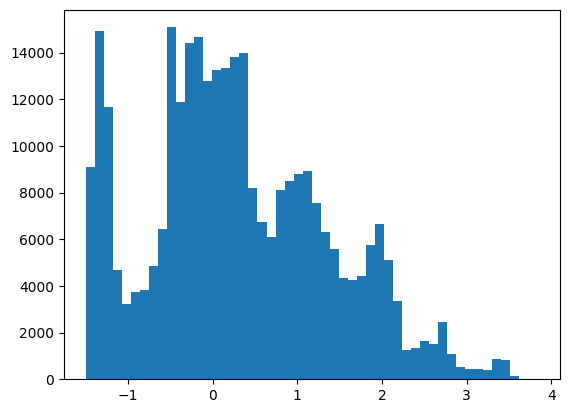

In [7]:
import open3d as o3d
import numpy as np
main_path = '/ssd/xiaxinyuan/code/w61-grutopia/thirdparty/landmark_isaacsim_interaction/rendered_imgs/sixth_floor/pcd/'
import matplotlib.pyplot as plt
# load pcd 100.pcd
pcd = o3d.io.read_point_cloud(main_path + '100.pcd')
# get the histgram of smallest z
x_values = np.array([point[0] for point in pcd.points])
y_values = np.array([point[1] for point in pcd.points])
z_values = np.array([point[2] for point in pcd.points])
print(x_values.min(), x_values.max())
print(y_values.min(), y_values.max())
print(z_values.min(), z_values.max())
# draw histgram
import matplotlib.pyplot as plt
_ = plt.hist(z_values, bins=50)


-7.893368244171143 0.8584812879562378
-2.059325695037842 5.682309627532959
-0.11914295703172684 2.694481611251831


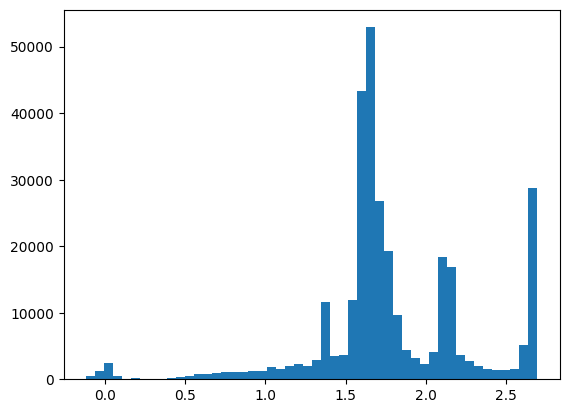

In [8]:
pcd = o3d.io.read_point_cloud(main_path + '200.pcd')
# get the histgram of smallest z
x_values = np.array([point[0] for point in pcd.points])
y_values = np.array([point[1] for point in pcd.points])
z_values = np.array([point[2] for point in pcd.points])
print(x_values.min(), x_values.max())
print(y_values.min(), y_values.max())
print(z_values.min(), z_values.max())
import matplotlib.pyplot as plt
_ = plt.hist(z_values, bins=50)


In [ ]:
# sort z_values from small to large
z_values = np.sort(z_values)
# get the 10% of the smallest z
print(np.mean(z_values[:20]))


0.9940729379653931


In [2]:

def test(a,b):
    a=3
    b=4
    print(a,b)

a=1
b=2
test(1,2)
print(a,b)

3 4
1 2
